## 3DoF Entry Cobra w/o Aoa SCP

Imports

In [ ]:
# Basic imports
import importlib
import numpy                as np
import matplotlib.pyplot    as plt
import pandas               as pd
import copy

# Trajopt imports --> pip install -e ~/ACL/trajopt
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp              as scp
import trajopt.core.Trajopt                         as prob
import trajopt.utils.config_loader                  as cfg
import trajopt.utils.tools                          as tools
import trajopt.analysis.default_analysis            as default_analysis
import trajopt.analysis.statistics                  as stats
import trajopt.core.modules.analysis.monte_carlo    as mc
import trajopt.core.modules.analysis.standalone     as standalone

from trajopt.analysis.trajplots import *


from trajopt.analysis.plots_for_scitech26_pdg import *

np.random.seed(0)  # for reproducibility



setup problem and run SCP

In [2]:
# if False: 
#     example_name = "cobra_entry_3dof"
#     nominal_config  = cfg.load_configs(example_name,local=True)

#     # either generate mc variations from yamls or load existing saved mc variations
#     gen_mc_variations    = 1

#     # save mc variations to file (specificy a name for this set of mc variations as well)
#     save_mc_variations   = 0
#     mc_name = "mc1"

#     # save scenario data to file (save the scenario data struct)
#     save_scenario_data   = 0

#     # run mc analysis loop
#     # TODO(Carlos and  Dan):  shouldn't need to return trajopt_obj, just scenario data, something below depends on it though (this is the most recent problem instance)
#     scenario_data, trajopt_obj = mc.run_mc_analysis(example_name, nominal_config, gen_mc_variations, save_mc_variations, save_scenario_data, mc_name,local=True)

# if True: 
#     example_name = "cobra_entry_3dof"
#     method_name = "autotune"
#     nominal_config  = cfg.load_configs(example_name, local=True)

#     # create problem instance
#     trajopt_obj = prob.Problem(nominal_config)

#     # run SCP
#     trajopt_obj = scp.run_scp(trajopt_obj)

#     # store scenario data struct for plotting
#     scenario_data = standalone.run_standalone_analysis(trajopt_obj, method_name)

mc analysis

In [3]:
# # file = '~/masters-link/ACL/prototypes/trajopt/src/trajopt/examples/vtol1_entry_3dof/data/statistics/mc1.txt' # Example file
# # analysis = stats.analyze_quality_metrics(scenario_data, filename=file)

# # Can run without filename if you don't want to save LaTeX tables
# if False: 
#     analysis = stats.analyze_quality_metrics(scenario_data)

In [4]:
example_name = "lander_6dof"
method_name = "standard"
nominal_config  = cfg.load_configs(example_name)

# create problem instance
trajopt_obj = prob.Problem(nominal_config)

# run SCP
trajopt_obj = scp.run_scp(trajopt_obj)

# store scenario data struct for plotting
scenario_data = standalone.run_standalone_analysis(trajopt_obj, method_name)

scales: 
d: 1.0000, t: 1.0000, m: 1.0000, v: 1.0000, a: 1.0000, f: 1.0000, ang: 57.2958, angv: 57.2958, none: 1.0000
Cost initial: 0.0
total number of parameters: 14628
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: lander: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
-------------------------------------------------------------------------------------------------------------------------------------

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    04501.8   |   0075.7  |   2285.6   |   -3.1    |      -12.0      |    -12.0    |     -00.3   |    optimal    |   4.50   |   0.0
     02     |    00029.7   |   0127.4  |   1945.0   |   +0.5    |      -12.0      |    -12.0    |     -00.2   |    optimal    |   4.00   |   0.0
     03     |    00050.7   |   0111.4  |   2029.4   |   +0.3    |      -12.0      |    -12.0    |     -00.1   |    optimal    |   3.64   |   0.0
     04     |    00030.9   |   0098.1  |   1637.2   |   +0.0    |      -12.0      |    -12.0    |     -00.2   |    optimal    |   3.98   |   0.0
     05     |    00035.5   |   0093.3  |   2131.1   |   +0.1    |      -12.0      |    -12.0    |     -01.2   |    optimal    |   4.35   |   0.0
     06     |    00043.2   |   0118.9  |   1924.1   |   -0.4    |      -12.0      |    -12.0    |     -02.7   |    optimal    |   4.85   |   0.0
     07     |    00040.6   |   0102.0  |   6705.6   |   -1.2    |      -12.0      |    -12.0    |     -03.9   |    optimal    |   

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/problems/trajopt_obj.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


     16     |    00015.9   |   0063.7  |   1200.2   |   -3.2    |      -12.0      |    -12.0    |     -04.7   |    optimal_inaccurate    |   4.91   |   0.0
     17     |    00018.6   |   0063.1  |   1629.6   |   -3.2    |      -12.0      |    -12.0    |     -04.5   |    optimal    |   4.91   |   0.0
     18     |    00029.7   |   0076.5  |   2374.5   |   -3.2    |      -12.0      |    -12.0    |     -04.4   |    optimal    |   4.91   |   0.0
     19     |    00021.5   |   0070.4  |   1617.2   |   -3.2    |      -12.0      |    -12.0    |     -04.6   |    optimal    |   4.90   |   0.0
     20     |    00020.4   |   0058.9  |   1723.9   |   -3.2    |      -12.0      |    -12.0    |     -04.9   |    optimal    |   4.90   |   0.0
     21     |    00018.0   |   0061.7  |   1924.4   |   -3.2    |      -12.0      |    -12.0    |     -04.6   |    optimal    |   4.90   |   0.0
     22     |    00037.8   |   0069.5  |   1553.4   |   -3.2    |      -12.0      |    -12.0    |     -04.6   |    opti

In [5]:
data = {'scenario1':scenario_data}
PLTS1 = SCVXPLOTS(data);
cases = {'scenarios':['scenario1'],'methods':['standard','autotune'],'runs':list(range(1000)),'iters':list(range(1000))[1:]}
preProcess(PLTS1,trajopt_obj,cases=cases);

/Users/carlosm/Documents/guidance/hypersonics/trajopt/src/trajopt/analysis/custom_functions_dan_pdg.py:52: RuntimeWarning: invalid value encountered in arccos
  return (180/np.pi)*np.arccos(1 - 2*(z[9]**2 + z[10]**2))


In [6]:
%load_ext autoreload
%autoreload 2

versions = ['standalone','sa_iters'];
figpaths = ['figs/standalone/','figs/standalone/'];

displayfigs = True;
printfigs = True; 
transparentfigs = True; 

specs = {}

specs['standalone'] = {'methods':[method_name],'runs':[0],'itrs':[]};
specs['sa_iters'] = {'methods':[method_name],'runs':[0],'itrs':list(range(1000))[1:]};
specs['methodvar'] = {'methods':['standard',method_name],'runs':[0]}; #,'itrs':list(range(1000))[1:]};
specs['mvmc'] = {'methods':['standard',method_name],'runs':list(range(10))}; #,'itrs':list(range(1000))[1:]};
specs['montecarlo'] = {'methods':['standard'],'runs':list(range(1000))}; #'itrs':list(range(1000))[1:]};

######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 
######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- ######## --- 

## default pens are set in the function plots_for_scitech26.py
## set new pens here. 
PENS = {};  

plotparams = {};
plotparams['trajopt_obj'] = trajopt_obj
plotparams['data'] = data;
plotparams['versions'] = versions;
plotparams['specs'] = specs;
plotparams['PENS'] = PENS;
plotparams['figpaths'] = figpaths;
plotparams['transparentfigs'] = transparentfigs;
plotparams['printfigs'] = printfigs;
plotparams['displayfigs'] = displayfigs;



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


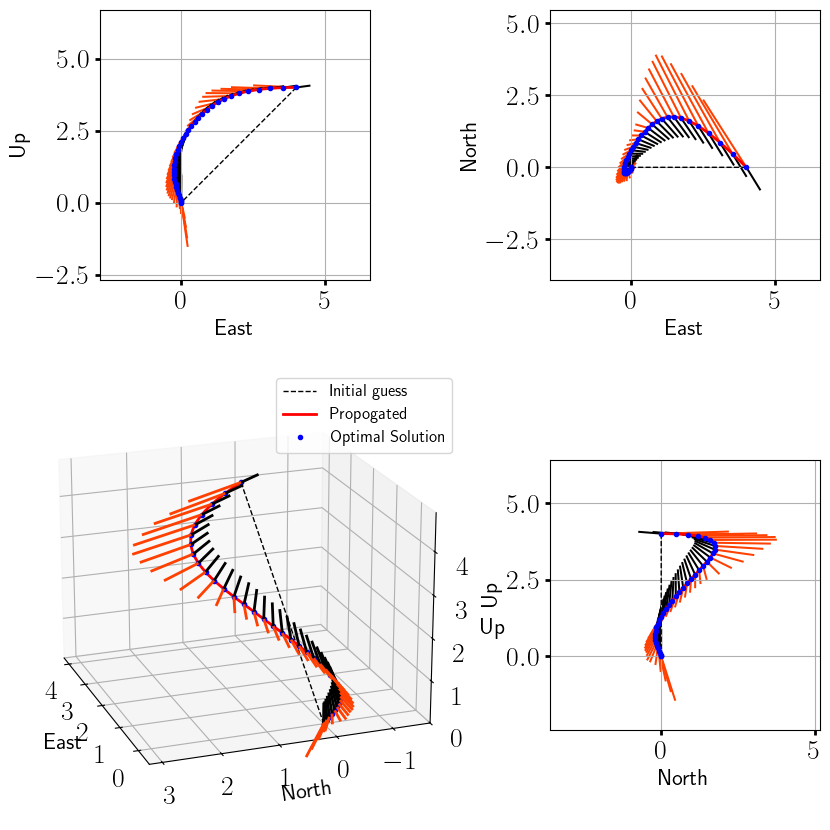

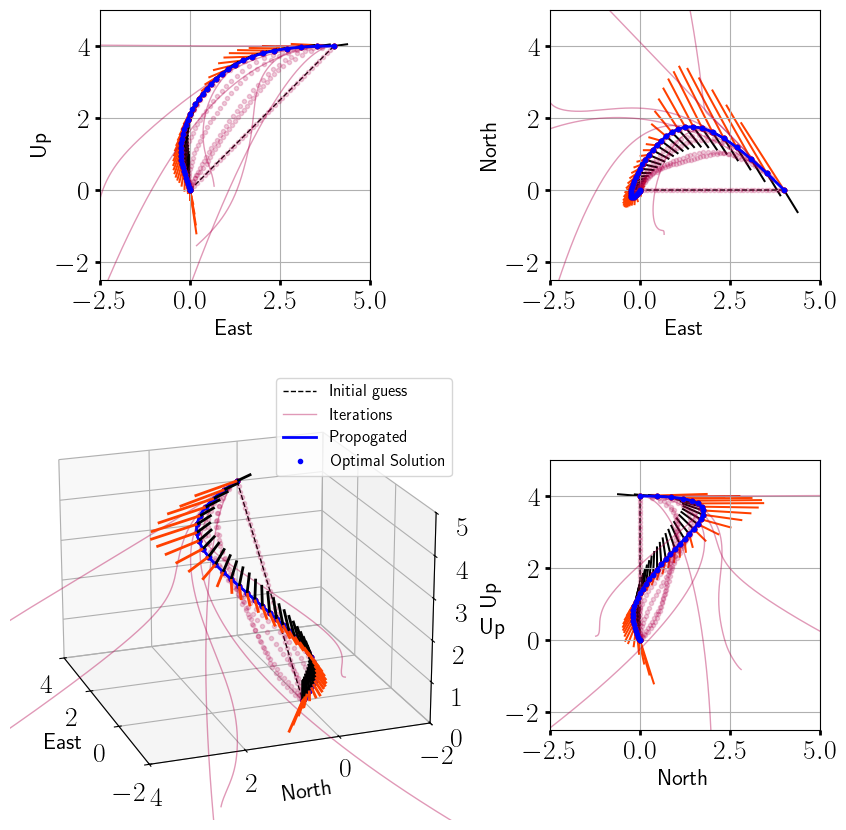

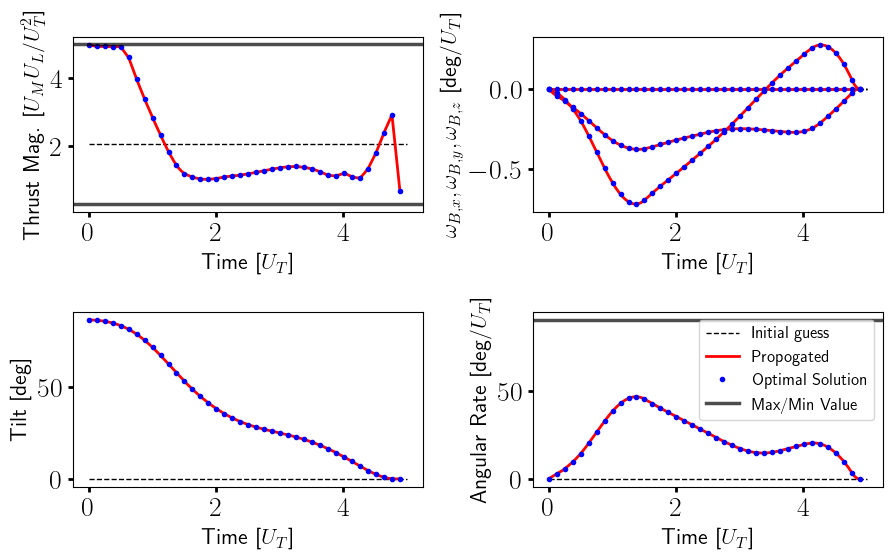

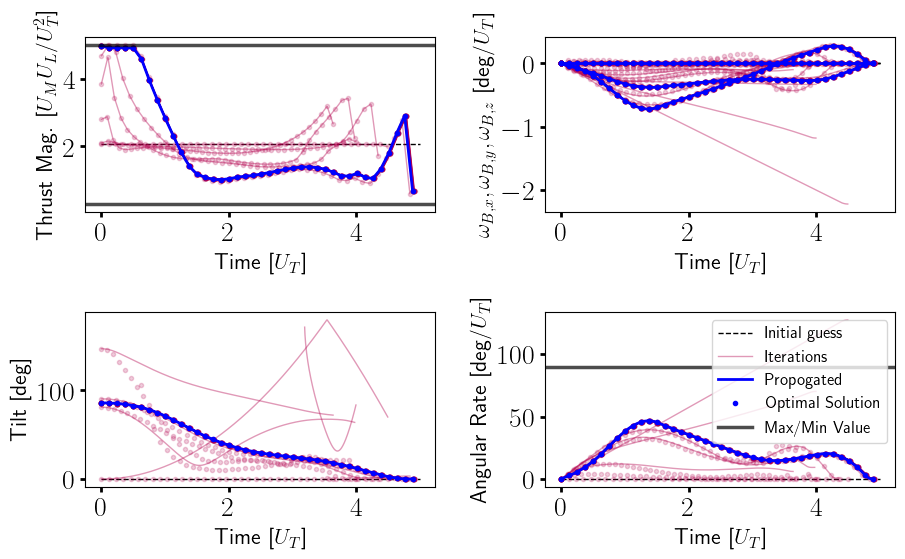

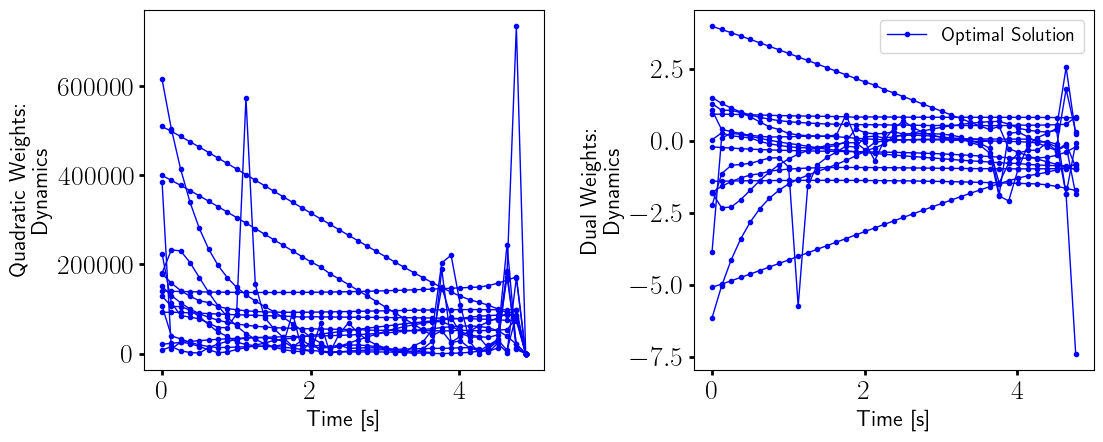

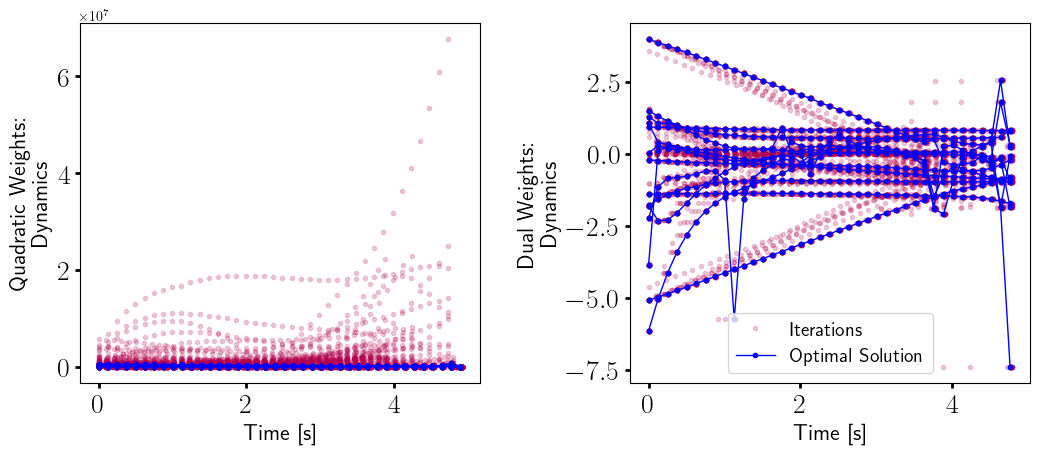

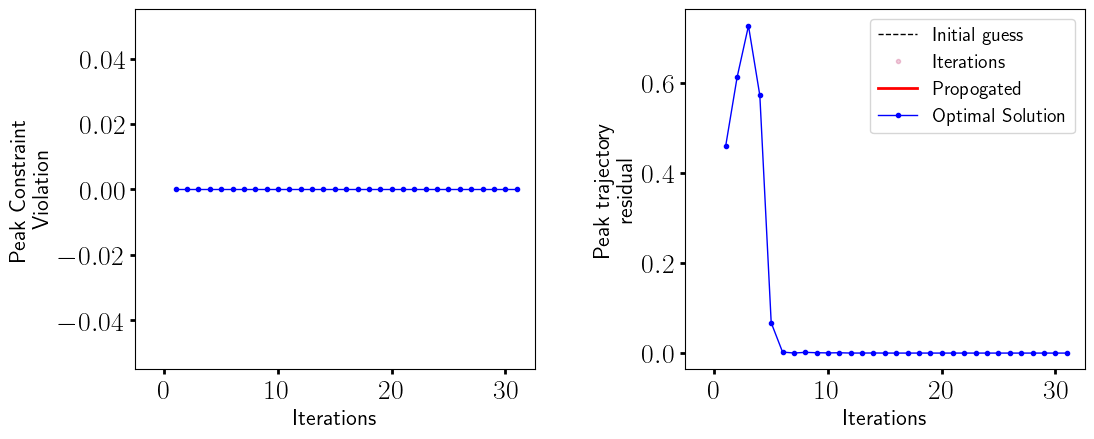

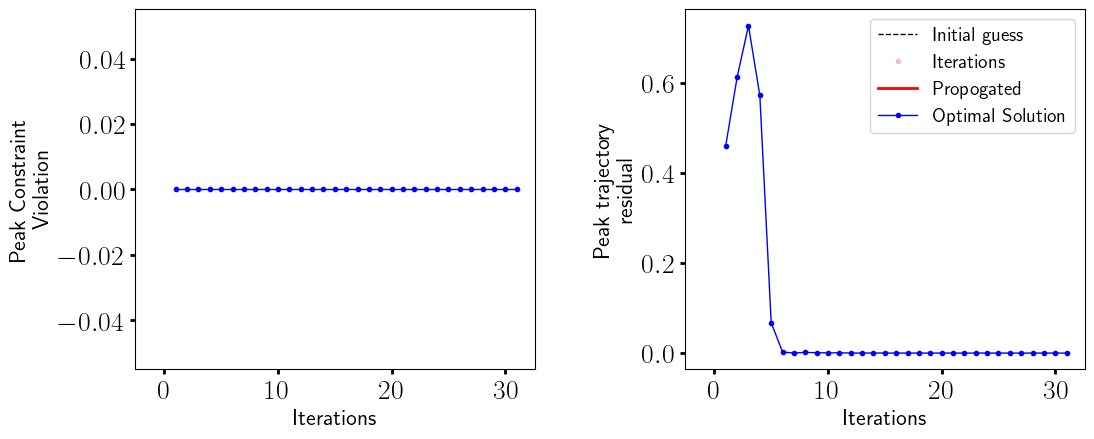

In [7]:
%load_ext autoreload
%autoreload 2

ALL_PLOTS = True
if ALL_PLOTS:

    newparams = {'usequiver':True,'sideviews':True,'skip':1}
    makePlotTrajs(PLTS1,ins={**plotparams,**newparams});
    
    makePlotStates(PLTS1,ins=plotparams);
    
    ### looks in 'weights' plots over time 
    newparams = {'weights_info':['W_dyn','dual_dyn']}
    # # # newparams = {'weights_info':[('W_dyn',(0)),('dual_dyn',(0,1))]}
    makePlotWghtsFlex(PLTS1,ins={**plotparams,**newparams});
    
    # ### looks in 'conv_data' plots over iterations
    # # newparams = {'converge_info':['chk_feas_term','chk_feas_dyn']}
    makePlotConvsFlex(PLTS1,ins={**plotparams,**newparams});
